<a href="https://colab.research.google.com/github/aldwsryshdha30-glitch/lab4/blob/main/lab4_DataProssesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Data Quality Assessment

In [1]:
import pandas as pd

df = pd.read_csv("ecommerce_user_behavior_8000.csv")

df.head()

# معلومات عامة
df.info()

# القيم المفقودة
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   object 
 3   device_type         7840 non-null   object 
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), object(2)
memory usage: 875.1+ KB


,0
user_id,160
age,160
gender,160
device_type,160
time_on_site,160
pages_viewed,160
previous_purchases,160
cart_items,160
discount_seen,160
ad_clicked,160


 Task 2: Handling Missing Values

In [ ]:
# Fill missing numeric values with the mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Verify no missing values remain
df.isnull().sum()

Mean is used because the data is numeric and the number of missing values is relatively small

 Task 3: Outliers Detection (IQR Method)

In [4]:
import numpy as np

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate Q1 and Q3
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# Compute IQR
IQR = Q3 - Q1

# Remove outliers from numeric columns only
df_clean = df[~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Check result
df_clean.shape

(7986, 14)

 Task 4: Normalization

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max normalization on numeric columns
scaler = MinMaxScaler()
df_minmax = scaler.fit_transform(df_clean.select_dtypes(include=np.number))

from sklearn.preprocessing import StandardScaler

# Apply Z-score normalization
scaler = StandardScaler()
df_zscore = scaler.fit_transform(df_clean.select_dtypes(include=np.number))

 Task 5: PCA (Principal Component Analysis)

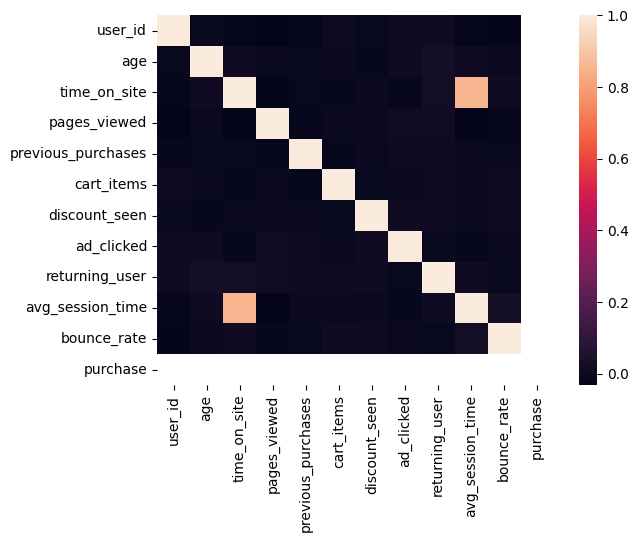

[0.16725782 0.09540262]


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Compute correlation matrix for numeric columns only
corr = df_clean.select_dtypes(include=np.number).corr()

# Visualize correlation heatmap
sns.heatmap(corr, annot=False)
plt.show()

# Ensure df_zscore is free of NaNs before applying PCA
# Identify rows with NaNs in df_zscore
nan_rows_mask = np.isnan(df_zscore).any(axis=1)

# Filter out rows containing NaNs to create a clean array for PCA
df_zscore_cleaned = df_zscore[~nan_rows_mask]

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore_cleaned)

# Print explained variance
print(pca.explained_variance_ratio_)